Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [3]:
json_dir = 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/'
years = np.arange(1980, 2030, 10)
paths = []

for year in years:
    paths.append(f'{json_dir}movies-{year}s.json')

print(paths)

['https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1980s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1990s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2000s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2010s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2020s.json']


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [4]:
dfs = []

for path in paths:
    dfs.append(pd.json_normalize(requests.get(path).json()))

dfs_united = pd.concat(dfs).drop(['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'], axis=1).dropna()

dfs_united

,title,year,cast,genres
0,Airplane!,1980,"[Robert Hays, Julie Hagerty, Leslie Nielsen, P...","[Comedy, Satire]"
1,Alex and the Doberman Gang,1980,"[Jack Stauffer, Taurean Blacque, Cindy Acker]","[Action, Comedy, Family]"
2,Alien Dead,1980,[Buster Crabbe],"[Science Fiction, Horror]"
3,Alligator,1980,"[Robert Forster, Robin Riker, Henry Silva, Dea...","[Horror, Independent]"
4,Altered States,1980,"[William Hurt, Blair Brown]","[Science Fiction, Horror]"
...,...,...,...,...
1148,Aquaman and the Lost Kingdom,2023,"[Jason Momoa, Amber Heard, Willem Dafoe, Patri...",[Superhero]
1149,Untitled Ghostbusters: Afterlife sequel,2023,"[Mckenna Grace, Carrie Coon, Finn Wolfhard, Pa...","[Comedy, Supernatural]"
1150,Rebel Moon,2023,"[Sofia Boutella, Charlie Hunnam, Ray Fisher, D...",[Science Fiction]
1151,Migration,2023,[],[]


3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [5]:
print(f'Our dataframe has {dfs_united.shape[0]} rows and {dfs_united.shape[1]} columns')
dfs_united.to_csv('movies_from_1980_to_2020.csv')

Our dataframe has 11216 rows and 4 columns


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [6]:
print(dfs_united.head(3))
print(dfs_united.info())

                        title  year  \
0                   Airplane!  1980   
1  Alex and the Doberman Gang  1980   
2                  Alien Dead  1980   

                                                cast  \
0  [Robert Hays, Julie Hagerty, Leslie Nielsen, P...   
1      [Jack Stauffer, Taurean Blacque, Cindy Acker]   
2                                    [Buster Crabbe]   

                      genres  
0           [Comedy, Satire]  
1   [Action, Comedy, Family]  
2  [Science Fiction, Horror]  
<class 'pandas.core.frame.DataFrame'>
Index: 11216 entries, 0 to 1152
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   11216 non-null  object
 1   year    11216 non-null  int64 
 2   cast    11216 non-null  object
 3   genres  11216 non-null  object
dtypes: int64(1), object(3)
memory usage: 438.1+ KB
None


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

genres
Comedy             3995
Drama              3801
Action             1537
Thriller           1430
Horror             1186
Romance            1113
Science Fiction     781
Crime               741
Fantasy             580
Animated            558
dtype: int64


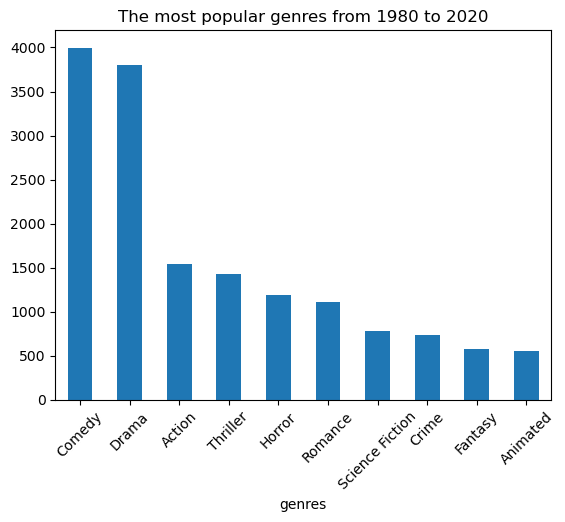

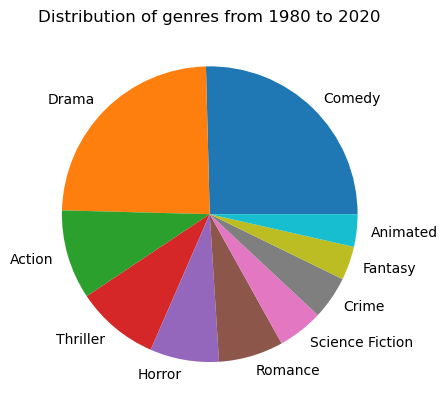

In [7]:
df_united_g = dfs_united.explode('genres').dropna()

genres_grouped = df_united_g.groupby('genres').size().sort_values(ascending=False)
print(genres_grouped.head(10))

genres_grouped.head(10).plot(kind='bar')
plt.title("The most popular genres from 1980 to 2020")
plt.xticks(rotation=45)
plt.show()

genres_grouped.head(10).plot(kind='pie')
plt.title("Distribution of genres from 1980 to 2020")
plt.show()

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

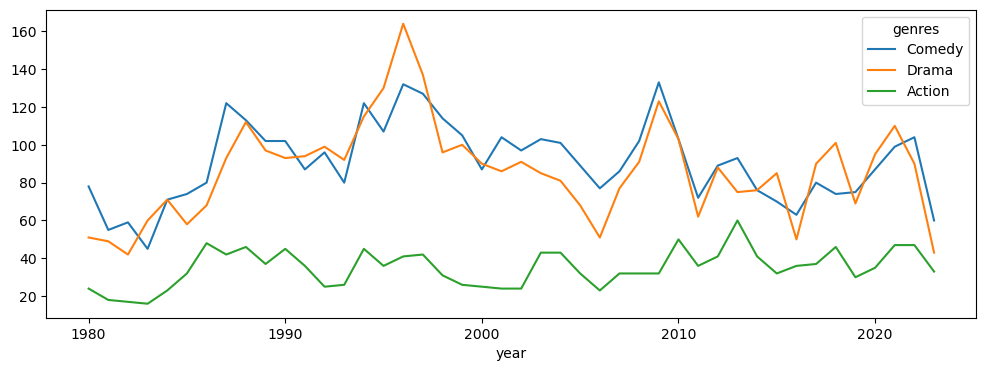

In [8]:
genres_by_years = df_united_g.groupby(['year', 'genres']).size().unstack().fillna(0).astype(int)
top_genres_by_years = genres_by_years[genres_by_years.sum().sort_values(ascending=False).head(3).index]

top_genres_by_years.plot(figsize=(12, 4))
plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

cast
Bruce Willis         104
Samuel L. Jackson     95
Robert De Niro        78
Morgan Freeman        72
Nicolas Cage          71
Liam Neeson           71
Dennis Quaid          69
Willem Dafoe          69
John Goodman          67
Julianne Moore        65
dtype: int64


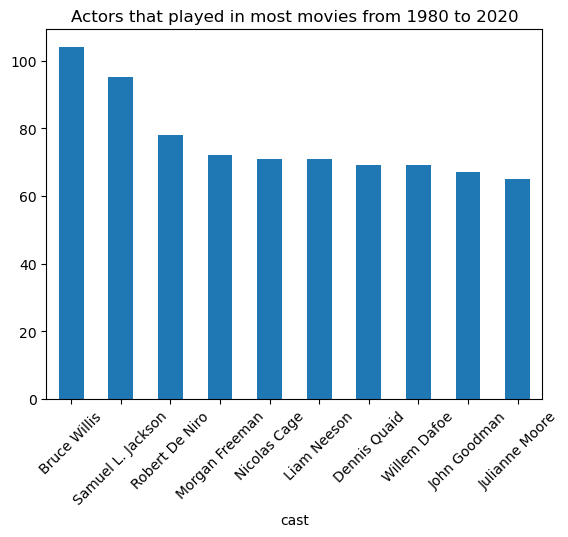

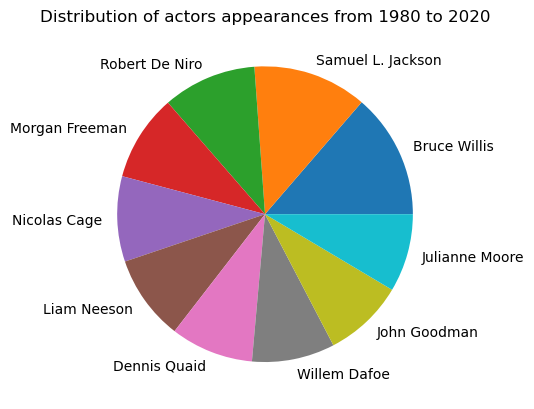

In [9]:
df_united_с = dfs_united.explode('cast').dropna()

cast_grouped = df_united_с.groupby('cast').size().sort_values(ascending=False)
print(cast_grouped.head(10))

cast_grouped.head(10).plot(kind='bar')
plt.title("Actors that played in most movies from 1980 to 2020")
plt.xticks(rotation=45)
plt.show()

cast_grouped.head(10).plot(kind='pie')
plt.title("Distribution of actors appearances from 1980 to 2020")
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

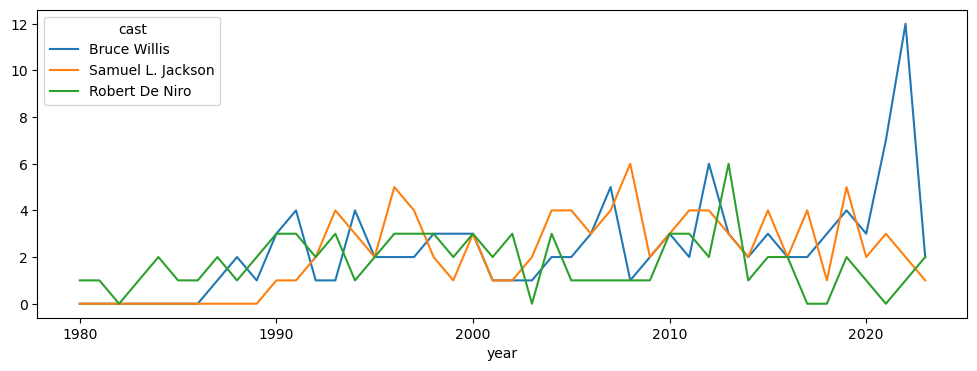

In [10]:
cast_by_years = df_united_с.groupby(['year', 'cast']).size().unstack().fillna(0).astype(int)
top_cast_by_years = cast_by_years[cast_by_years.sum().sort_values(ascending=False).head(3).index]

top_cast_by_years.plot(figsize=(12, 4))
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

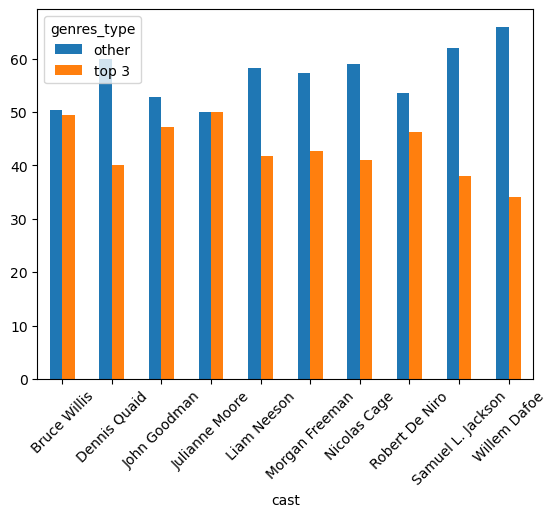

genres_type        other_count  top 3_count  other_pct  top 3_pct
cast                                                             
Bruce Willis               109          107      50.46      49.54
Dennis Quaid                97           65      59.88      40.12
John Goodman                77           69      52.74      47.26
Julianne Moore              61           61      50.00      50.00
Liam Neeson                 88           63      58.28      41.72
Morgan Freeman              79           59      57.25      42.75
Nicolas Cage                89           62      58.94      41.06
Robert De Niro              88           76      53.66      46.34
Samuel L. Jackson          109           67      61.93      38.07
Willem Dafoe                91           47      65.94      34.06


In [36]:
dsf_united_opened = dfs_united.explode('genres').explode('cast')

top_genres = genres_grouped.head(3).index
top_cast = cast_grouped.head(10).index

dsf_united_opened = dsf_united_opened[dsf_united_opened['cast'].isin(top_cast)]
dsf_united_opened['genres_type'] = np.where(dsf_united_opened['genres'].isin(top_genres), 'top 3', 'other')

dsf_united_opened_grouped = dsf_united_opened.pivot_table(
    index='cast',
    columns='genres_type',
    aggfunc='size',
    fill_value=0
)

dsf_pct = (dsf_united_opened_grouped.div(
    dsf_united_opened_grouped.sum(axis=1),
    axis=0
) * 100).round(2)

result_table = dsf_united_opened_grouped.join(dsf_pct, lsuffix='_count', rsuffix='_pct')

dsf_pct.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

print(result_table)